<a href="https://colab.research.google.com/github/RomanPikhotskiy/dsp-seminars/blob/pikhotskiy_r/seminars/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

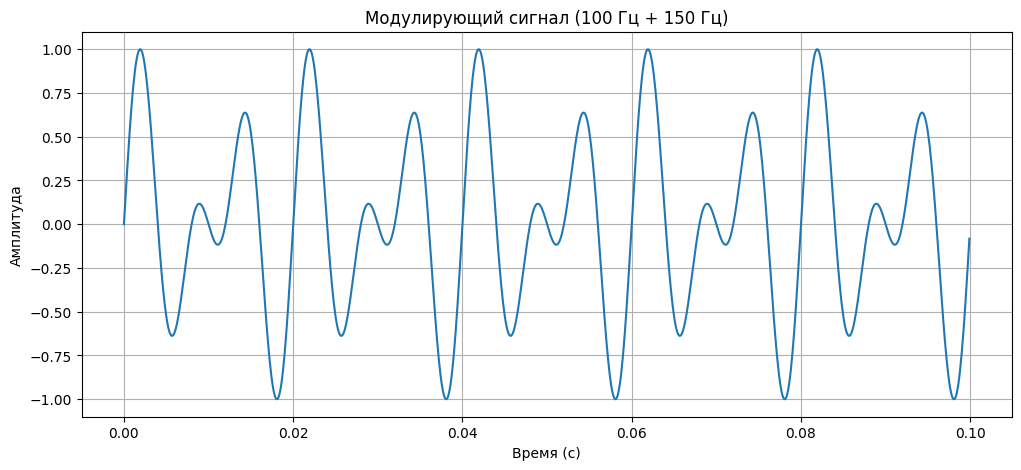

In [3]:
fm1 = 100
fm2 = 150

m_t = np.sin(2*np.pi*fm1*t) + np.sin(2*np.pi*fm2*t)
m_t = m_t / np.max(np.abs(m_t))   # нормализация в [-1, 1]

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 150 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [4]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [5]:
beta_pm = 5
s_pm = Ac * np.cos(2*np.pi*fc*t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

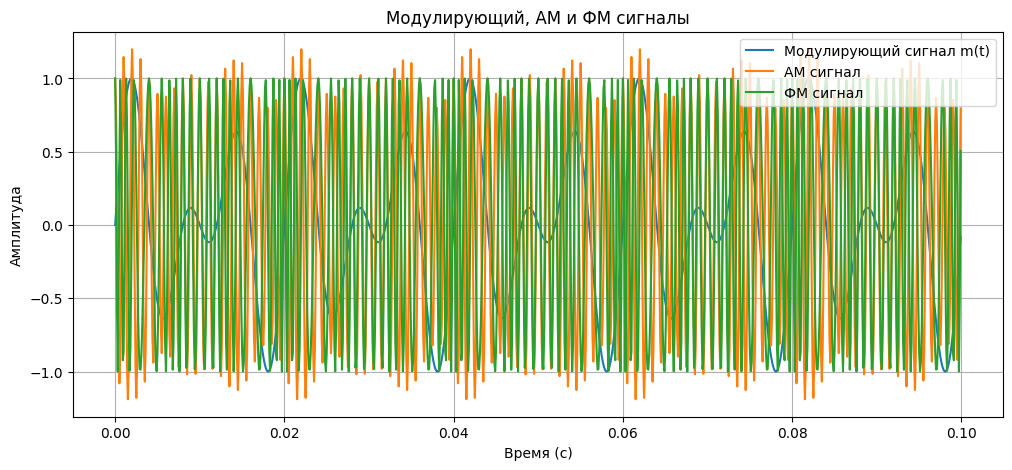

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(t, m_t, label='Модулирующий сигнал m(t)')
plt.plot(t, s_am, label='АМ сигнал')
plt.plot(t, s_pm, label='ФМ сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Модулирующий, АМ и ФМ сигналы')
plt.legend()
plt.grid(True)
plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [7]:
def plot_spectrum(s, fs, title):
    N = len(s)
    S = np.fft.fft(s)
    freqs = np.fft.fftfreq(N, d=1/fs)

    pos_mask = freqs >= 0
    freqs_pos = freqs[pos_mask]
    amp_pos = 2 * np.abs(S[pos_mask]) / N

    plt.figure(figsize=(12, 4))
    plt.plot(freqs_pos, amp_pos)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.title(title)
    plt.grid(True)
    plt.xlim(0, fs/2)
    plt.show()


### 2.2. Спектр АМ

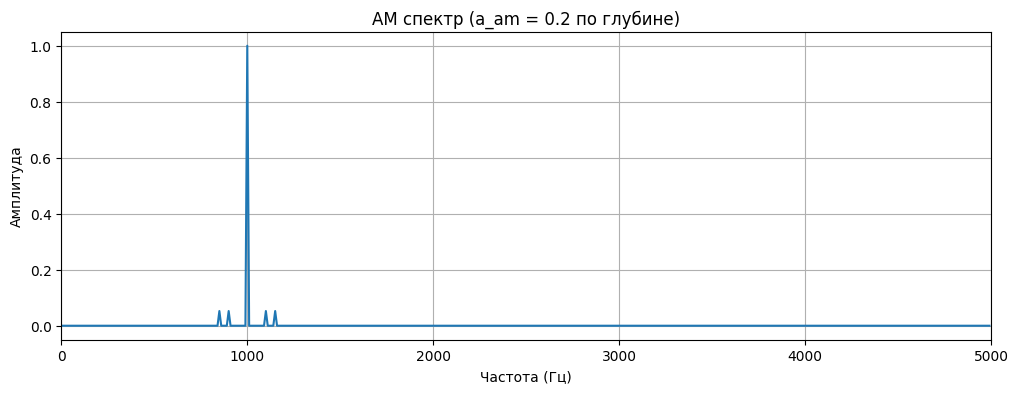

In [10]:
plot_spectrum(s_am, fs, f'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

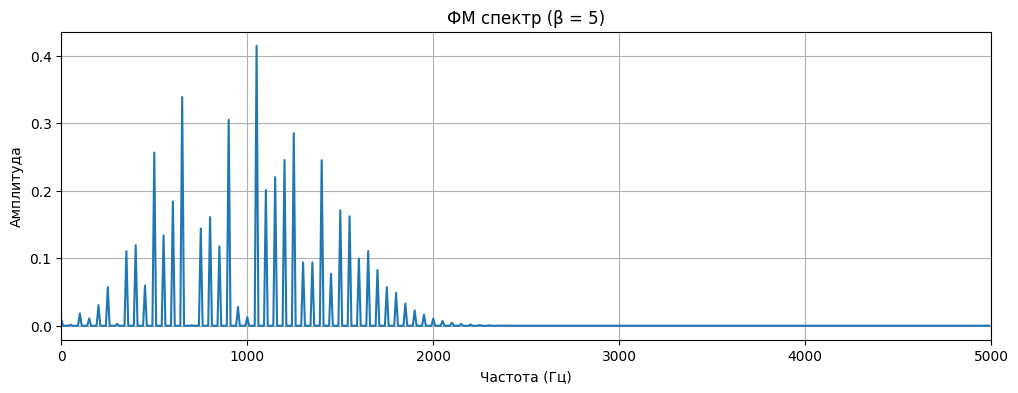

In [11]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

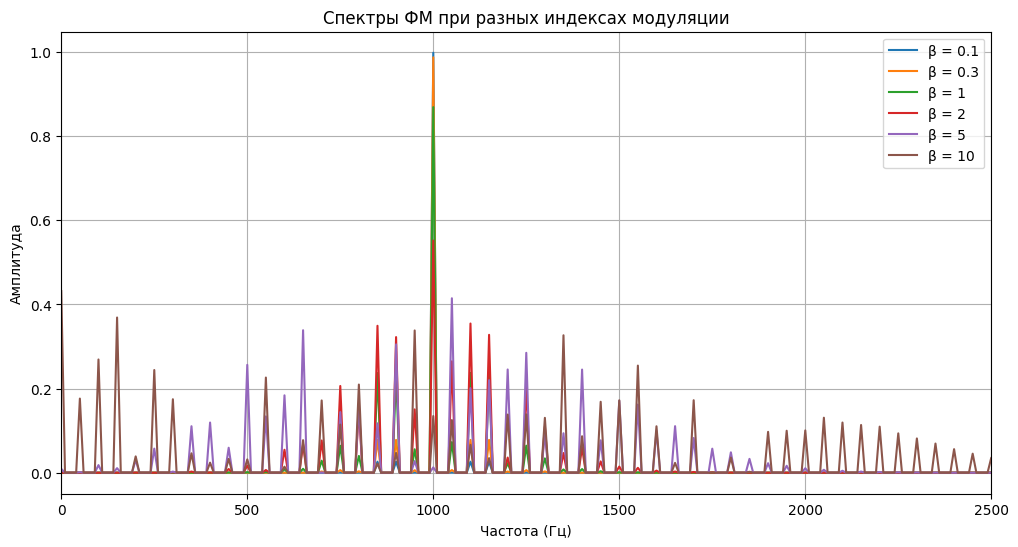

In [12]:
betas = [0.1, 0.3, 1, 2, 5, 10]

plt.figure(figsize=(12, 6))
for beta in betas:
    s_pm_beta = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)

    N = len(s_pm_beta)
    S = np.fft.fft(s_pm_beta)
    freqs = np.fft.fftfreq(N, d=1/fs)

    pos_mask = freqs >= 0
    freqs_pos = freqs[pos_mask]
    amp_pos = 2 * np.abs(S[pos_mask]) / N

    plt.plot(freqs_pos, amp_pos, label=f'β = {beta}')

plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектры ФМ при разных индексах модуляции')
plt.legend()
plt.grid(True)
plt.xlim(0, 2500)
plt.show()

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [13]:
def pm_spectrum(beta=5):
    s_pm_beta = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)

    N = len(s_pm_beta)
    S = np.fft.fft(s_pm_beta)
    freqs = np.fft.fftfreq(N, d=1/fs)

    pos_mask = freqs >= 0
    freqs_pos = freqs[pos_mask]
    amp_pos = 2 * np.abs(S[pos_mask]) / N

    plt.figure(figsize=(12, 4))
    plt.plot(freqs_pos, amp_pos)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.title(f'Спектр ФМ-сигнала при β = {beta}')
    plt.grid(True)
    plt.xlim(0, 3000)
    plt.show()


widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

Спектр АМ содержит пять ярко выраженных компонент, потому что модулирующий сигнал состоит из двух синусоидальных составляющих. Каждая из них создаёт по две боковые полосы около несущей: на частотах $f_c \pm f_{m1}$ и $f_c \pm f_{m2}$. Вместе с самой несущей это даёт 5 основных линий: несущая и четыре боковые компоненты.

При малых значениях $\beta$ спектр ФМ похож на спектр узкополосного углового сигнала: заметна сильная несущая и только первые боковые полосы, расположенные симметрично относительно неё.

При увеличении $\beta$ энергия перераспределяется от несущей к большему числу боковых полос. Амплитуда несущей обычно уменьшается, а спектр становится шире, так как появляются всё более удалённые гармоники.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

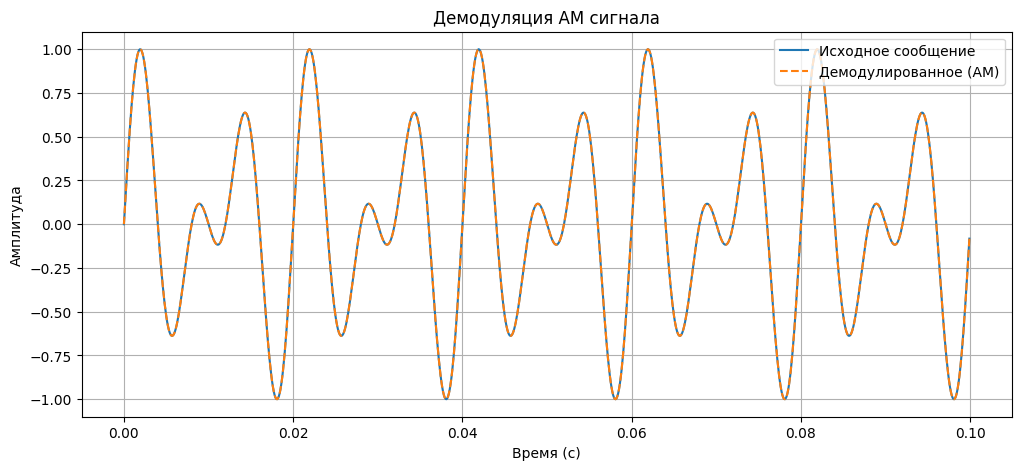

In [14]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [15]:
mse_am = np.std(m_t - demod_am)
print(f'Среднеквадратичная ошибка АМ-демодуляции: {mse_am:.6f}')

Среднеквадратичная ошибка АМ-демодуляции: 0.000000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

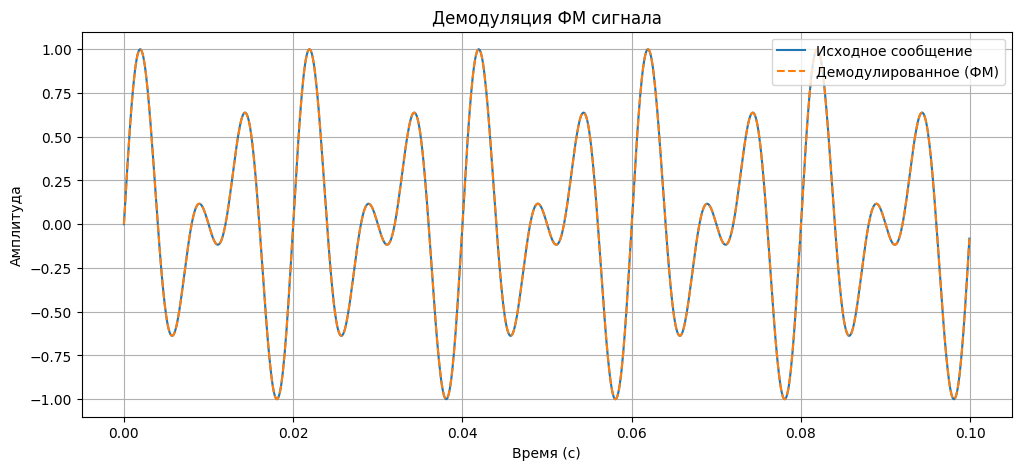

In [16]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

Функция `np.unwrap` нужна для устранения скачков фазы на $\pm \pi$. Без неё мгновенная фаза после вычисления через `np.angle` будет иметь разрывы, из-за чего восстановленный сигнал получится искажённым. `unwrap` делает фазу непрерывной и позволяет корректно выделить полезное отклонение фазы от линейного тренда несущей.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [17]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-03-28 20:15:50--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-03-28 20:15:51--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.006s  

2026-03-28 20:15:52 (93.8 MB/s) - ‘audio.wav’ saved [563756/563756]



In [18]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

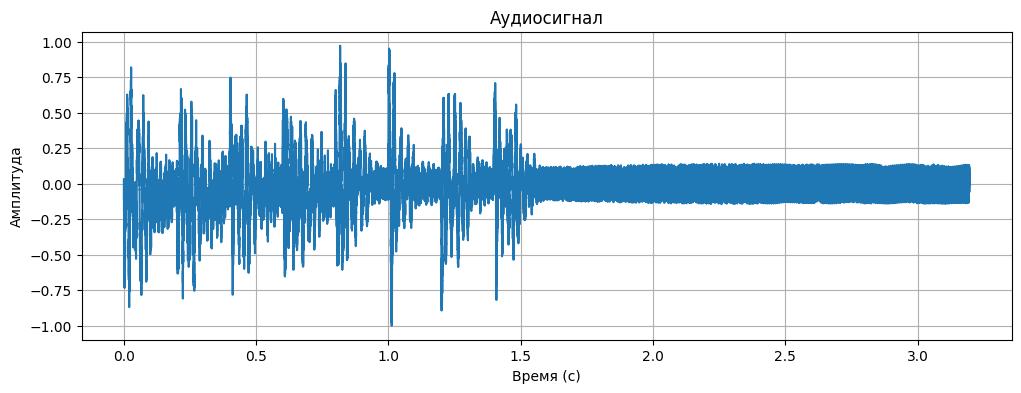

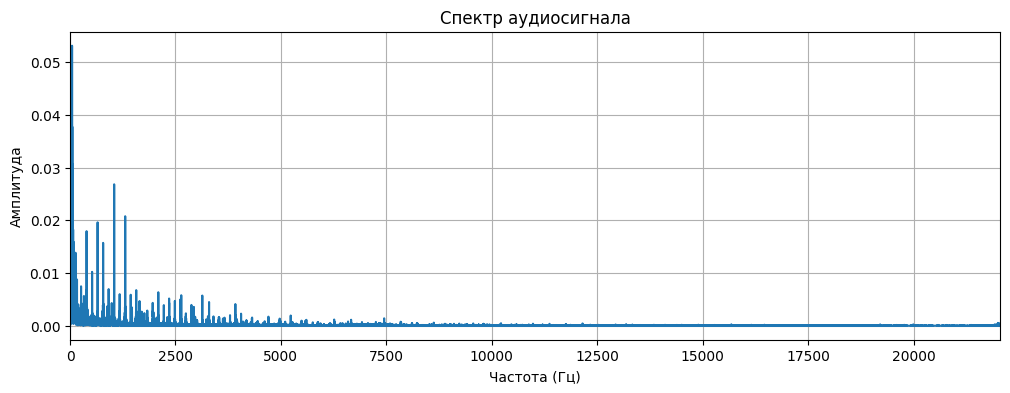

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(t_audio, melody)
plt.title('Аудиосигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

plot_spectrum(melody, fs_audio, 'Спектр аудиосигнала')

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

В спектре аудиосигнала заметные пики обычно наблюдаются в области низких и средних частот, примерно до нескольких килогерц. При частоте дискретизации 44,1 кГц несущую нужно выбирать достаточно высокой, чтобы модулированный спектр не пересекался с исходной низкочастотной областью, но при этом оставался ниже частоты Найквиста. Поэтому разумно выбирать несущую порядка 5–10 кГц.

При увеличении индекса модуляции ФМ спектр расширяется, так как появляется больше боковых полос. Поэтому слишком большой индекс модуляции требует выбирать несущую и запас по полосе более осторожно, чтобы избежать наложения спектров и искажений.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [20]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [21]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [22]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [23]:
analytic_am_audio = hilbert(s_am_audio)
envelope_audio = np.abs(analytic_am_audio)
demod_am_audio = (envelope_audio - Ac) / a_am
demod_am_audio = demod_am_audio / np.max(np.abs(demod_am_audio))

print("Демодулированное АМ без шума:")
display(Audio(demod_am_audio, rate=fs_audio))

Демодулированное АМ без шума:


Демодулируйте зашумлёный АМ-сигнал.

In [24]:
analytic_am_noisy = hilbert(s_am_noisy)
envelope_am_noisy = np.abs(analytic_am_noisy)
demod_am_noisy = (envelope_am_noisy - Ac) / a_am
demod_am_noisy = demod_am_noisy / np.max(np.abs(demod_am_noisy))

print("Демодулированное АМ с шумом:")
display(Audio(demod_am_noisy, rate=fs_audio))

Демодулированное АМ с шумом:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

После демодуляции АМ без шума качество звука изменяется незначительно. При добавлении амплитудного шума искажения становятся слышны довольно быстро, так как информация в АМ содержится именно в огибающей, а шум напрямую искажает её.

При фиксированном $a_{AM}=0.2$ заметная разница с оригиналом обычно начинает прослушиваться уже при сравнительно небольших уровнях шума. Чем больше амплитуда шума, тем сильнее искажается восстановленный сигнал.

Если зафиксировать шум, то при слишком маленьком $a_{AM}$ полезная модуляция оказывается слабой по сравнению с шумом, и качество заметно ухудшается. При увеличении $a_{AM}$ устойчивость к шуму возрастает. Следовательно, допустимый уровень шума связан с глубиной модуляции: чем больше $a_{AM}$, тем лучше помехоустойчивость, но $a_{AM}$ не должен превышать 1, чтобы не возникала перемодуляция.

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [25]:
analytic_pm_audio = hilbert(s_pm_audio)
inst_phase_audio = np.unwrap(np.angle(analytic_pm_audio))
phase_no_carrier_audio = inst_phase_audio - 2*np.pi*fc_high*t_audio
demod_pm_audio = phase_no_carrier_audio - np.mean(phase_no_carrier_audio)
demod_pm_audio = demod_pm_audio / beta_pm_audio
demod_pm_audio = demod_pm_audio / np.max(np.abs(demod_pm_audio))

print("Демодулированное ФМ без шума:")
display(Audio(demod_pm_audio, rate=fs_audio))

Демодулированное ФМ без шума:


Демодулируйте зашумлёный ФМ-сигнал.

In [26]:
analytic_pm_noisy = hilbert(s_pm_noisy)
inst_phase_noisy = np.unwrap(np.angle(analytic_pm_noisy))
phase_no_carrier_noisy = inst_phase_noisy - 2*np.pi*fc_high*t_audio
demod_pm_noisy = phase_no_carrier_noisy - np.mean(phase_no_carrier_noisy)
demod_pm_noisy = demod_pm_noisy / beta_pm_audio
demod_pm_noisy = demod_pm_noisy / np.max(np.abs(demod_pm_noisy))

print("Демодулированное ФМ с шумом:")
display(Audio(demod_pm_noisy, rate=fs_audio))

Демодулированное ФМ с шумом:


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

После демодуляции ФМ без шума качество звука почти не меняется. При наличии амплитудного шума ФМ-сигнал обычно оказывается более устойчивым, чем АМ, потому что полезная информация содержится в фазе, а не в амплитуде.

При фиксированном $\beta = 2$ заметные искажения появляются при больших амплитудах шума, чем в случае АМ. Это говорит о лучшей устойчивости ФМ к амплитудным помехам.

Если зафиксировать шум и увеличивать $\beta$, то относительное влияние шума на восстановленный сигнал уменьшается, потому что полезное фазовое отклонение становится более выраженным. Однако слишком большой $\beta$ расширяет спектр и может приводить к дополнительным искажениям из-за слишком широкой полосы.

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

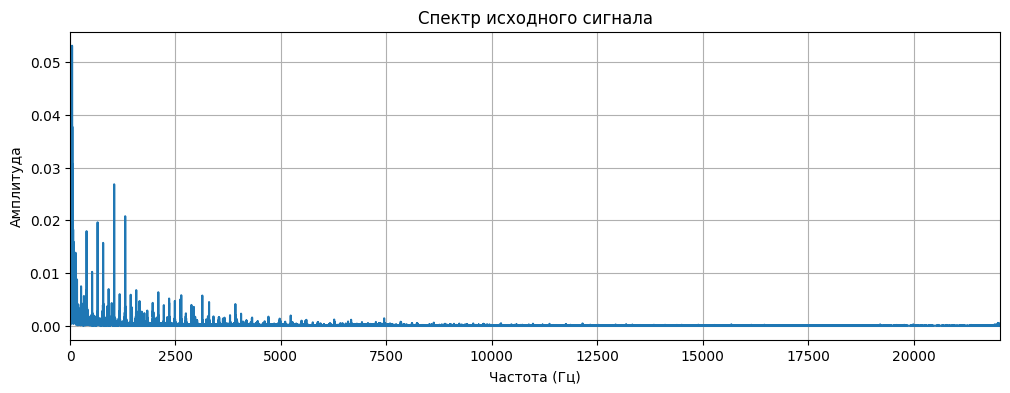

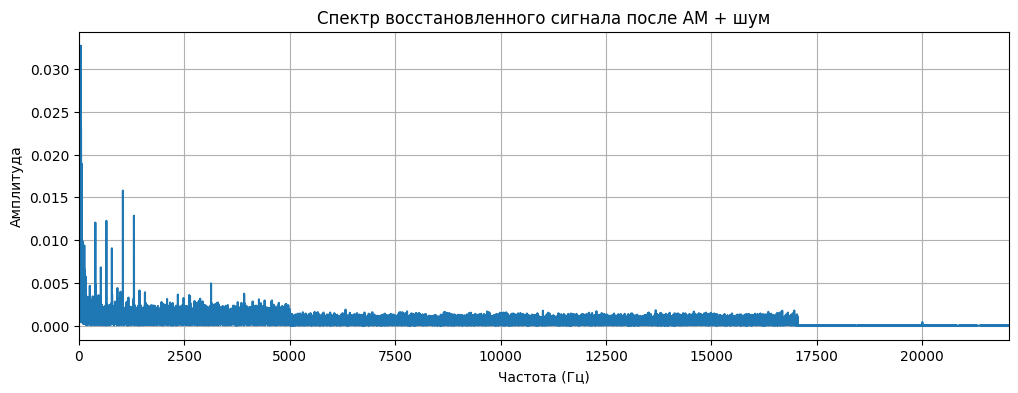

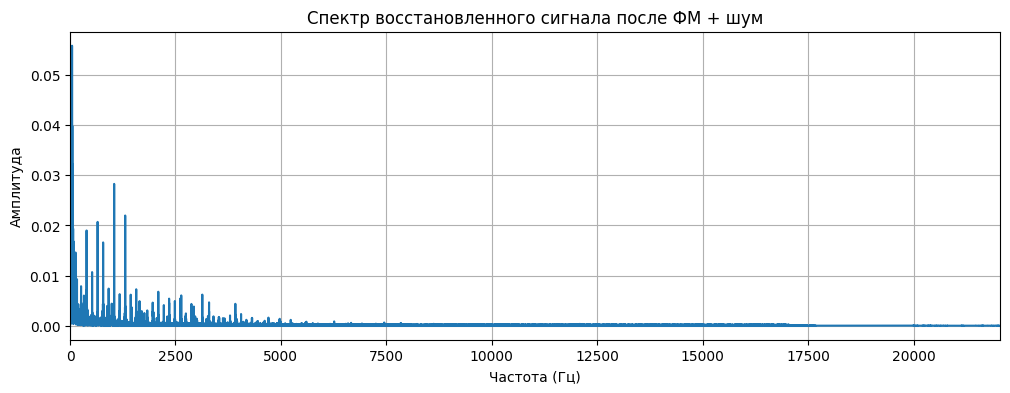

In [28]:
noise_amp = 0.05
a_am = 0.2
beta_pm_audio = 2

s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

noise = noise_amp * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise)
s_pm_noisy = s_pm_audio * (1 + noise)

analytic_am_noisy = hilbert(s_am_noisy)
env_am_noisy = np.abs(analytic_am_noisy)
demod_am_noisy = (env_am_noisy - Ac) / a_am
demod_am_noisy = demod_am_noisy / np.max(np.abs(demod_am_noisy))

analytic_pm_noisy = hilbert(s_pm_noisy)
inst_phase_noisy = np.unwrap(np.angle(analytic_pm_noisy))
phase_no_carrier_noisy = inst_phase_noisy - 2*np.pi*fc_high*t_audio
demod_pm_noisy = phase_no_carrier_noisy - np.mean(phase_no_carrier_noisy)
demod_pm_noisy = demod_pm_noisy / beta_pm_audio
demod_pm_noisy = demod_pm_noisy / np.max(np.abs(demod_pm_noisy))

plot_spectrum(melody, fs_audio, 'Спектр исходного сигнала')
plot_spectrum(demod_am_noisy, fs_audio, 'Спектр восстановленного сигнала после АМ + шум')
plot_spectrum(demod_pm_noisy, fs_audio, 'Спектр восстановленного сигнала после ФМ + шум')

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

Визуально искажения спектров восстановленных сигналов заметны, но в случае АМ они обычно выражены сильнее: появляются дополнительные искажения амплитуд основных гармоник и фоновые составляющие. В случае ФМ спектр восстановленного сигнала обычно ближе к исходному, поэтому визуально и субъективно искажения меньше.

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

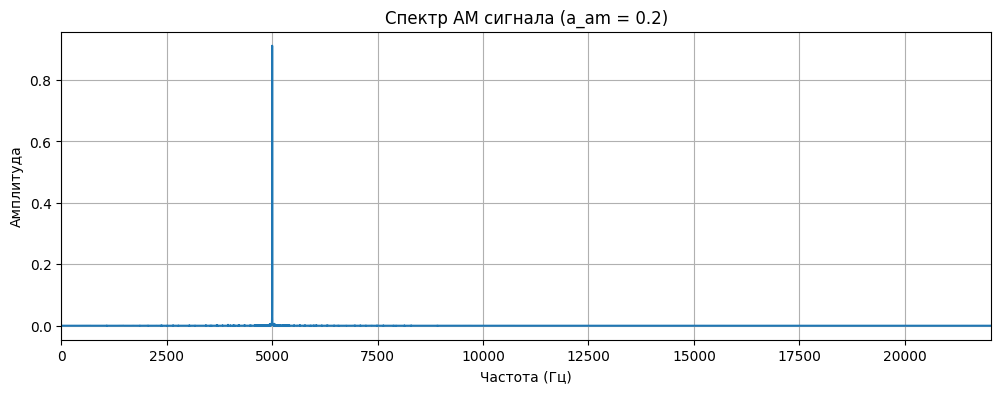

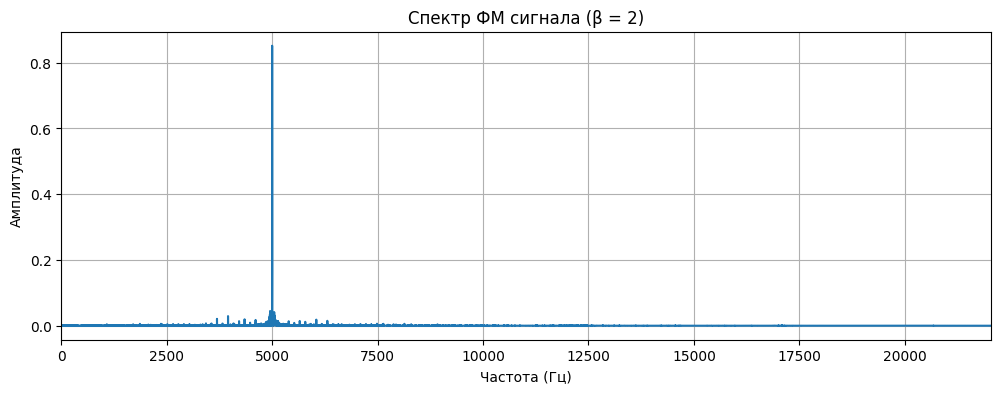

In [29]:
beta_pm_audio = 2
a_am = 0.2

s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

plot_spectrum(s_am_audio, fs_audio, f'Спектр АМ сигнала (a_am = {a_am})')
plot_spectrum(s_pm_audio, fs_audio, f'Спектр ФМ сигнала (β = {beta_pm_audio})')

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

При сопоставимых амплитудах гармоник АМ-сигнал начинает заметно искажаться при меньшей амплитуде шума, чем ФМ-сигнал. Для ФМ допустимый уровень амплитудного шума оказывается выше.

Вывод: при амплитудных помехах фазовая модуляция более устойчива, чем амплитудная, поскольку полезная информация в ФМ кодируется фазой, а не амплитудой. Поэтому амплитудный шум сильнее портит АМ-сигнал и слабее влияет на ФМ.